# DSAI 4103 project - Airbnb Price Prediction
# Farah Abu-Shariha - 60104384

## Business Problem

Airbnb hosts often struggle to price their listings optimally. Setting the price too high pushes potential guests away, while pricing too low leaves revenue on the table. This project builds a machine learning pipeline that **predicts the nightly price of an Airbnb listing** based on its features city, room type, host activity, availability, calendar pricing patterns, and review history.



This project aims to identify the key drivers of Airbnb listing prices, build a model that predicts nightly price accurately, and evaluate whether that model treats all cities and room types fairly.


Three Datasets were used
- listings.csv : Airbnb listings across 10 cities — host info, room type, price, location
- reviews.csv : guest reviews linked to listing IDs — used to compute review volume per listing
- calendar.csv : Inside Airbnb (Paris) | Day-by-day availability and dynamic calendar price for each listing — gives a richer price signal than the static listing price alone

**Dataset Sources:** Airbnb Listings & Reviews    
Link: Inside Airbnb (https://mavenanalytics.io/data-playground/airbnb-listings-reviews)

calendar.csv: (https://data.insideairbnb.com/france/ile-de-france/paris/2024-09-06/data/calendar.csv.gz)  



## Section 1 — Imports and Configuration

In [85]:
#import urllib.request
#import gzip
#import shutil
#import os

# Paris calendar from Inside Airbnb — this snapshot contains real price data
#url         = 'https://data.insideairbnb.com/france/ile-de-france/paris/2024-09-06/data/calendar.csv.gz'
#gz_path     = 'calendar_paris.csv.gz'
#output_path = 'calendar.csv'

#print("Downloading calendar file... this may take a minute.")
#urllib.request.urlretrieve(url, gz_path)

#print("Extracting...")
#with gzip.open(gz_path, 'rb') as f_in:
#    with open(output_path, 'wb') as f_out:
#        shutil.copyfileobj(f_in, f_out)

# Clean up the compressed file — we only need the CSV
#os.remove(gz_path)
#print("Done! calendar.csv is ready.")

In [86]:
!pip install shap

In [87]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import json
import re

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor, VotingRegressor)
from sklearn.linear_model import Ridge
import shap
import joblib

print("All libraries imported")

All libraries imported



## Section 2 — Data Collection

We load all three datasets and look at their structure, size, and column names.

In [88]:
# Load Dataset 1: Listings
# listings.csv covers 279,712 Airbnb listings across 10 global cities.
# latin-1 encoding is required due to special characters in listing names.
# The column 'listing_id' is renamed to 'id' to match the rest of the pipeline.

listings = pd.read_csv('listings.csv', encoding='latin-1')
listings = listings.rename(columns={'listing_id': 'id'})
print(f"Dataset 1 — listings.csv:  {listings.shape[0]:,} rows × {listings.shape[1]} columns")

Dataset 1 — listings.csv:  279,712 rows × 33 columns


In [89]:
# Load Dataset 2: Reviews 
reviews = pd.read_csv('reviews.csv', encoding='latin-1')
print(f"Dataset 2 — reviews.csv:   {reviews.shape[0]:,} rows × {reviews.shape[1]} columns")

Dataset 2 — reviews.csv:   5,373,143 rows × 4 columns


In [90]:
# Load Dataset 3: Calendar 
# Each row= one specific day for one listing.
# Columns:listing_id, date, available (t/f), price (calendar price that day),adjusted_price, minimum_nights, maximum_nights

# because Airbnb hosts can set DIFFERENT prices for different dates (weekends, holidays, etc.), the calendar captures this dynamic pricing
# reality that the static listings.csv price alone cannot show.

calendar = pd.read_csv('calendar.csv')
print(f"Dataset 3 — calendar.csv:  {calendar.shape[0]:,} rows × {calendar.shape[1]} columns")
print(f"\nCalendar columns: {list(calendar.columns)}")

Dataset 3 — calendar.csv:  34,842,829 rows × 7 columns

Calendar columns: ['listing_id', 'date', 'available', 'price', 'adjusted_price', 'minimum_nights', 'maximum_nights']


In [91]:
listings = listings.rename(columns={
    'host_total_listings_count': 'host_listings_count'
})

price_count= calendar['price'].notna().sum()
print(f"Calendar rows with a price value: {price_count:,}")

Calendar rows with a price value: 34,842,829


In [92]:
# Sample the calendar down to 5 million rows for performance
calendar= calendar.sample(n=5_000_000, random_state=42).reset_index(drop=True)
print(f"Calendar sampled to: {len(calendar):,} rows")

Calendar sampled to: 5,000,000 rows


In [93]:
available_rows = calendar[calendar['available'] == 't'].head(10)
print(f"Total available days in calendar: {(calendar['available'] == 't').sum():,}")
print(f"Total days with a price value:    {calendar['price'].notna().sum():,}")
print()
print("First 5 rows where listing IS available (should show prices):")
print(available_rows[['listing_id', 'date', 'available', 'price']].to_string())

Total available days in calendar: 1,741,005
Total days with a price value:    5,000,000

First 5 rows where listing IS available (should show prices):
             listing_id        date available      price
2   1196393134718980158  2025-04-02         t    $144.00
5              51627418  2025-05-24         t  $2,640.00
9               2018724  2025-08-22         t    $875.00
12  1039067948234576204  2025-04-07         t    $210.00
14  1123309217751553233  2025-02-15         t     $35.00
19  1046953206709746429  2025-03-21         t     $95.00
21  1150513192003311884  2025-05-30         t    $300.00
22  1136752486357091935  2025-02-02         t    $200.00
25  1102074822111658528  2024-12-31         t    $222.00
26             35159761  2025-04-09         t    $110.00


In [94]:
print("listings.csv — first 3 rows")
listings.head(3)

listings.csv — first 3 rows


,id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [95]:
print("reviews.csv — first 3 rows")
reviews.head(3)

reviews.csv — first 3 rows


,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378


In [96]:
print("calendar.csv — first 3 rows")
calendar.head(3)

calendar.csv — first 3 rows


,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,963722328741162466,2024-09-13,f,$300.00,NaN,2.0,12.0
1,13089618,2025-05-06,f,$40.00,NaN,365.0,1125.0
2,1196393134718980158,2025-04-02,t,$144.00,NaN,1.0,365.0


In [97]:
# Schema info for all datasets
print("listings.csv — info")
listings.info()
print()
print("reviews.csv — info")
reviews.info()
print()
print("calendar.csv — info")
calendar.info()

listings.csv — info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_listings_count          279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 no


## Section 3 — Exploratory Data Analysis (EDA)


In [98]:
# 3.1 Statistical Summary — Listings
print("Statistical Summary — listings.csv")
listings.describe(include='all').T

Statistical Summary — listings.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,279712.0,NaN,NaN,NaN,26381955.489825,14425758.688779,2577.0,13844618.75,27670985.0,39784850.75,48343530.0
name,279537,265860,home away from home,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,279712.0,NaN,NaN,NaN,108165773.085531,110856993.215898,1822.0,17206558.0,58269113.5,183285318.75,390187445.0
host_since,279547,4240,2019-09-02,710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_location,278872,7159,"Paris, Ile-de-France, France",47794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_response_time,150930,4,within an hour,83464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_response_rate,150930.0,NaN,NaN,NaN,0.865939,0.283744,0.0,0.9,1.0,1.0,1.0
host_acceptance_rate,166625.0,NaN,NaN,NaN,0.827168,0.289202,0.0,0.78,0.98,1.0,1.0
host_is_superhost,279547,2,f,229294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_listings_count,279547.0,NaN,NaN,NaN,24.581612,284.041143,0.0,1.0,1.0,4.0,7235.0


In [99]:
# 3.2 Missing Value Analysis
missing_count= listings.isnull().sum()
missing_pct= (missing_count / len(listings) * 100).round(2)
missing_df= pd.DataFrame({'Missing Count': missing_count, 'Missing (%)': missing_pct})
print("Columns with Missing Values")
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

Columns with Missing Values


,Missing Count,Missing (%)
district,242700,86.77
host_response_time,128782,46.04
host_response_rate,128782,46.04
host_acceptance_rate,113087,40.43
review_scores_value,91785,32.81
review_scores_location,91775,32.81
review_scores_checkin,91771,32.81
review_scores_accuracy,91713,32.79
review_scores_communication,91687,32.78
review_scores_cleanliness,91665,32.77


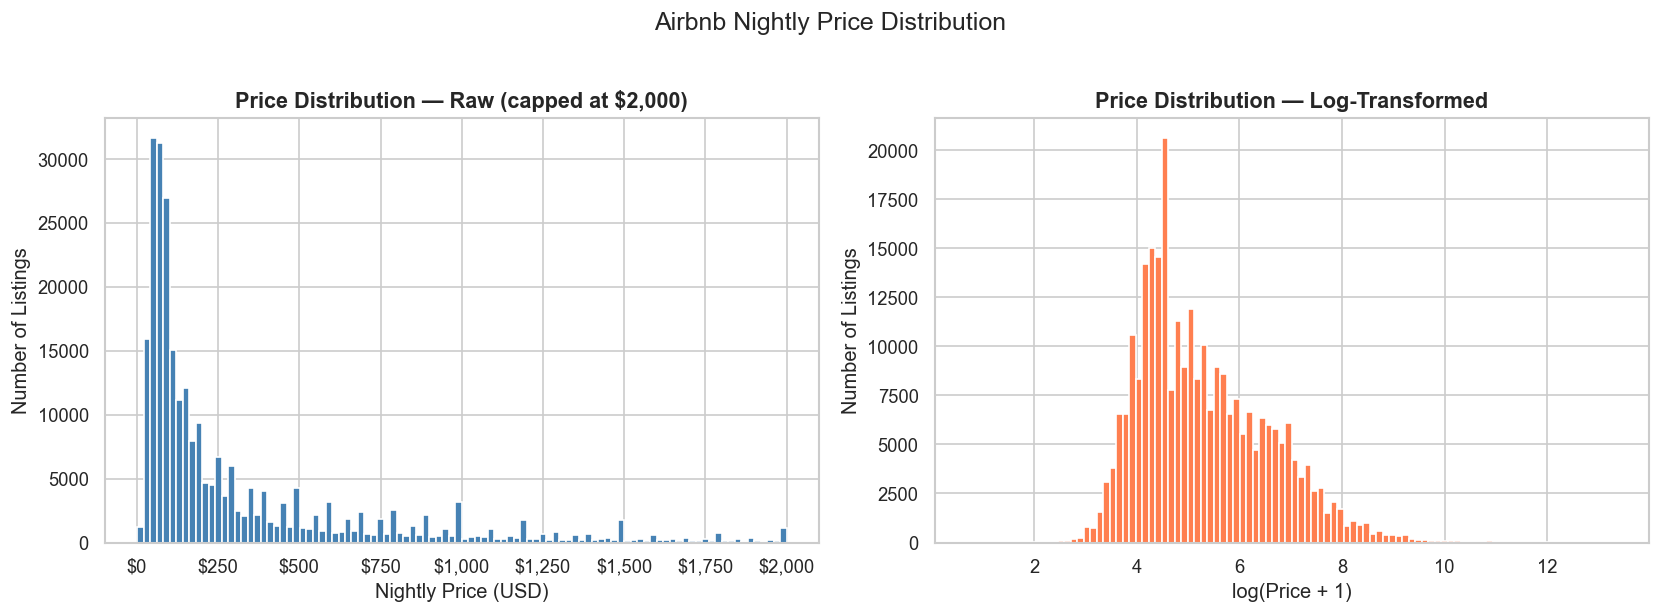

Total listings with valid price: 279,599
After capping at $2,000:         266,115 (95.2% of listings)
Min price:    $1
Median price: $140
Mean price:   $315
Max price (capped): $2,000
Max price (raw):    $625,216  ← clear outlier/data error


In [100]:
# 3.3 Price Distribution — Raw vs Log-Transformed
price_clean= listings['price'].dropna()
price_clean= price_clean[price_clean > 0]
price_clean_capped= price_clean[price_clean <= 2000]  

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(price_clean_capped, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution — Raw (capped at $2,000)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nightly Price (USD)')
axes[0].set_ylabel('Number of Listings')
axes[0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${int(x):,}')
)


axes[1].hist(np.log1p(price_clean), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution — Log-Transformed',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Number of Listings')

plt.suptitle('Airbnb Nightly Price Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('eda_01_price_distribution.png', bbox_inches='tight')
plt.show()

# Print summary statistics 
print(f"Total listings with valid price: {len(price_clean):,}")
print(f"After capping at $2,000:         {len(price_clean_capped):,} "
      f"({len(price_clean_capped)/len(price_clean)*100:.1f}% of listings)")
print(f"Min price:    ${price_clean_capped.min():,.0f}")
print(f"Median price: ${price_clean_capped.median():,.0f}")
print(f"Mean price:   ${price_clean_capped.mean():,.0f}")
print(f"Max price (capped): ${price_clean_capped.max():,.0f}")
print(f"Max price (raw):    ${price_clean.max():,.0f}  ← clear outlier/data error")

In [101]:
# Print all column names so we can see exactly what is available
print(listings.columns.tolist())

['id', 'name', 'host_id', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'district', 'city', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable']


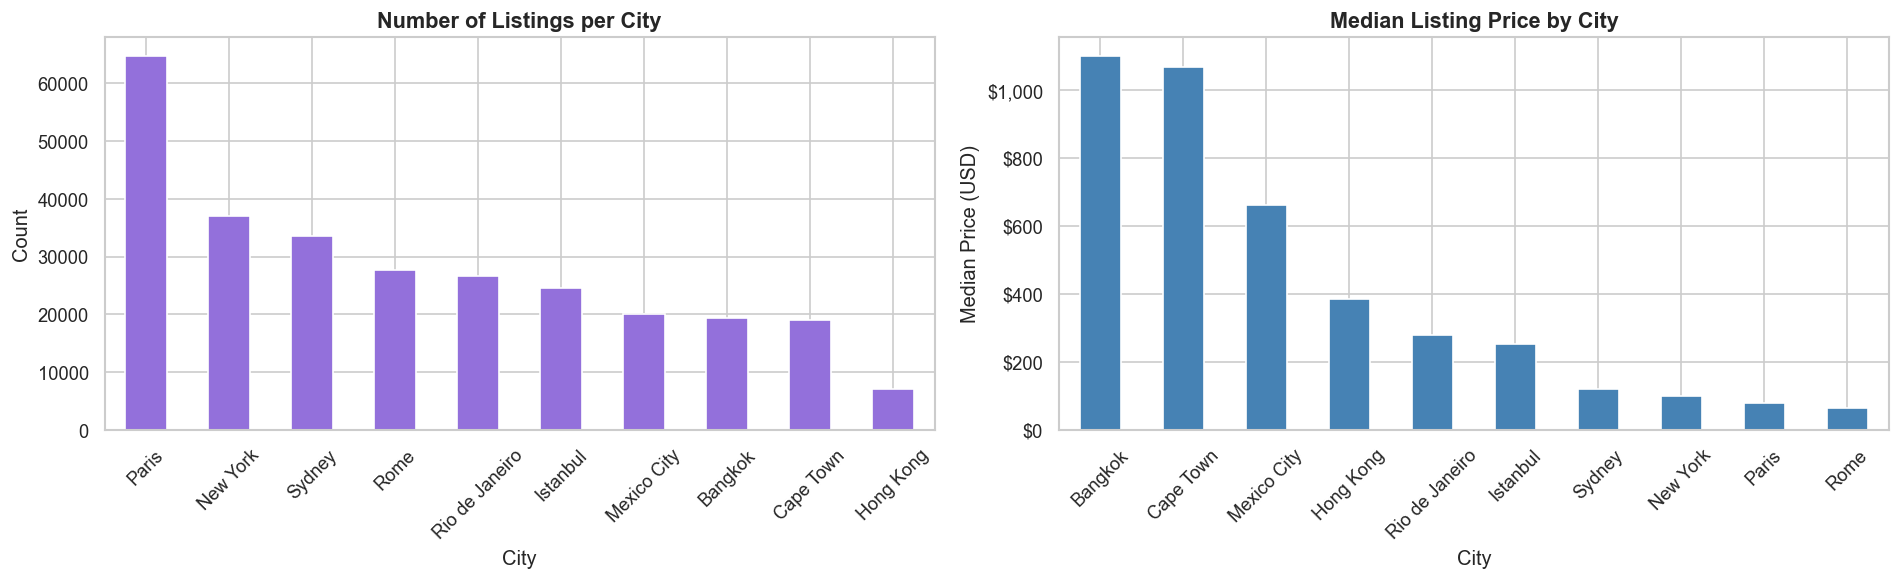

In [102]:
# 3.4 Listings Count and Median Price by City
city_stats = listings.groupby('city').agg(
    listing_count=('id', 'count'),   # changed 'listing_id' to 'id'
    median_price=('price', 'median')
).sort_values('median_price', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

city_stats['listing_count'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white'
)
axes[0].set_title('Number of Listings per City', fontsize=13, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

city_stats['median_price'].plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Median Listing Price by City', fontsize=13, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Median Price (USD)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${int(x):,}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_02_city_analysis.png', bbox_inches='tight')
plt.show()

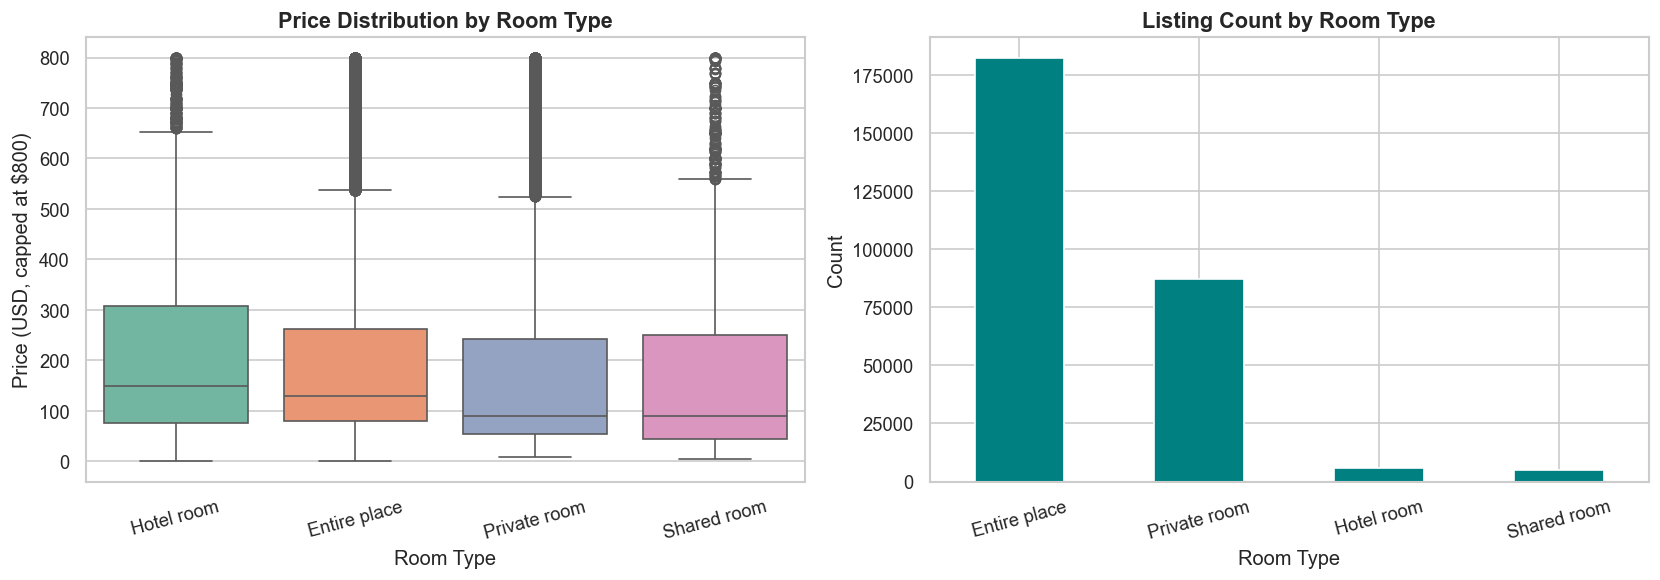

In [103]:
# 3.5 Price by Room Type
room_order= listings.groupby('room_type')['price'].median().sort_values(ascending=False).index

fig, axes= plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=listings[listings['price'] <= 800],
    x='room_type', y='price',
    order=room_order, palette='Set2', ax=axes[0]
)
axes[0].set_title('Price Distribution by Room Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price (USD, capped at $800)')
axes[0].tick_params(axis='x', rotation=15)

listings['room_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title('Listing Count by Room Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('eda_03_room_type.png', bbox_inches='tight')
plt.show()

In [104]:
# 3.6 Calendar Analysis — Availability and Dynamic Pricing
# The Paris calendar stores prices as strings like '$100.00'
# We strip the dollar sign and comma, then convert to float.

def parse_price(price_str):
    if pd.isna(price_str):
        return np.nan
    cleaned = re.sub(r'[\$,\s]', '', str(price_str))
    try:
        return float(cleaned)
    except:
        return np.nan

calendar['price_numeric']  = calendar['price'].apply(parse_price)
calendar['date']           = pd.to_datetime(calendar['date'], errors='coerce')
calendar['available_flag'] = (calendar['available'].astype(str).str.lower() == 't').astype(int)

# Verify the parsing worked 
rows_with_price = calendar['price_numeric'].notna().sum()
print(f"Calendar date range:        {calendar['date'].min().date()} to {calendar['date'].max().date()}")
print(f"Unique listings in calendar:{calendar['listing_id'].nunique():,}")
print(f"Rows with actual price data:{rows_with_price:,}")
print(f"Overall availability rate:  {calendar['available_flag'].mean()*100:.1f}%")
print(f"Sample parsed prices: {calendar['price_numeric'].dropna().head(5).values}")

Calendar date range:        2024-09-06 to 2025-09-12
Unique listings in calendar:95,461
Rows with actual price data:5,000,000
Overall availability rate:  34.8%
Sample parsed prices: [300.  40. 144.  91. 120.]


Rows available for chart: 4,941,586


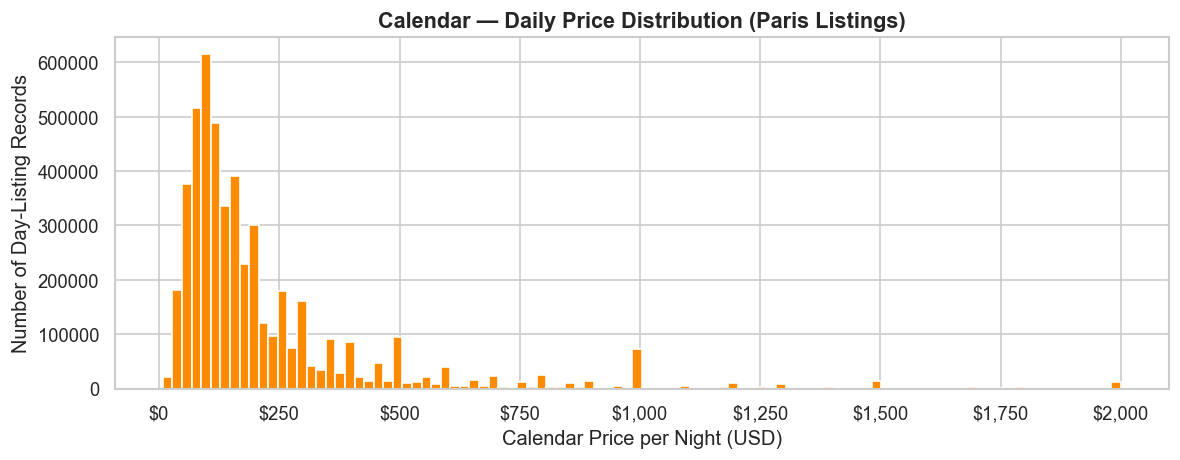

In [105]:
# 3.6a Calendar Price Distribution
# Filter to only rows where a price actually exists and is within range
cal_prices = calendar['price_numeric'].dropna()
cal_prices = cal_prices[(cal_prices > 0) & (cal_prices <= 2000)]

print(f"Rows available for chart: {len(cal_prices):,}")  # confirm data exists

plt.figure(figsize=(10, 4))
plt.hist(cal_prices, bins=100, color='darkorange', edgecolor='white')
plt.title('Calendar — Daily Price Distribution (Paris Listings)', fontsize=13, fontweight='bold')
plt.xlabel('Calendar Price per Night (USD)')
plt.ylabel('Number of Day-Listing Records')
plt.gca().xaxis.set_major_formatter(          # fixed the broken formatter line
    mtick.FuncFormatter(lambda x, _: f'${int(x):,}')
)
plt.tight_layout()
plt.savefig('eda_04_calendar_price.png', bbox_inches='tight')
plt.show()

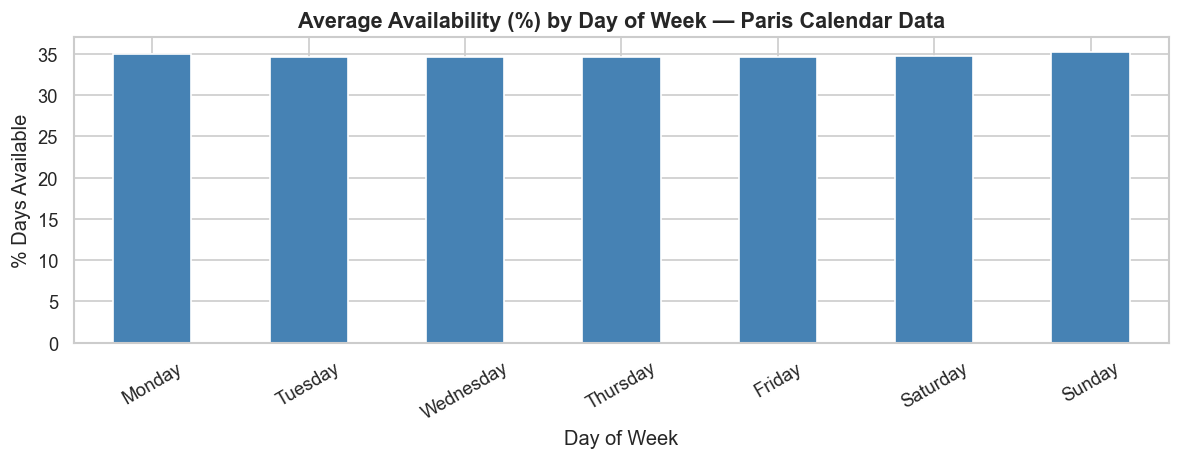

In [106]:
# 3.6b Availability by Day of Week
calendar['day_of_week'] = calendar['date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

avail_by_day = calendar.groupby('day_of_week')['available_flag'].mean().reindex(day_order) * 100

plt.figure(figsize=(10, 4))
avail_by_day.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Availability (%) by Day of Week — Paris Calendar Data', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('% Days Available')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('eda_05_availability_by_day.png', bbox_inches='tight')
plt.show()


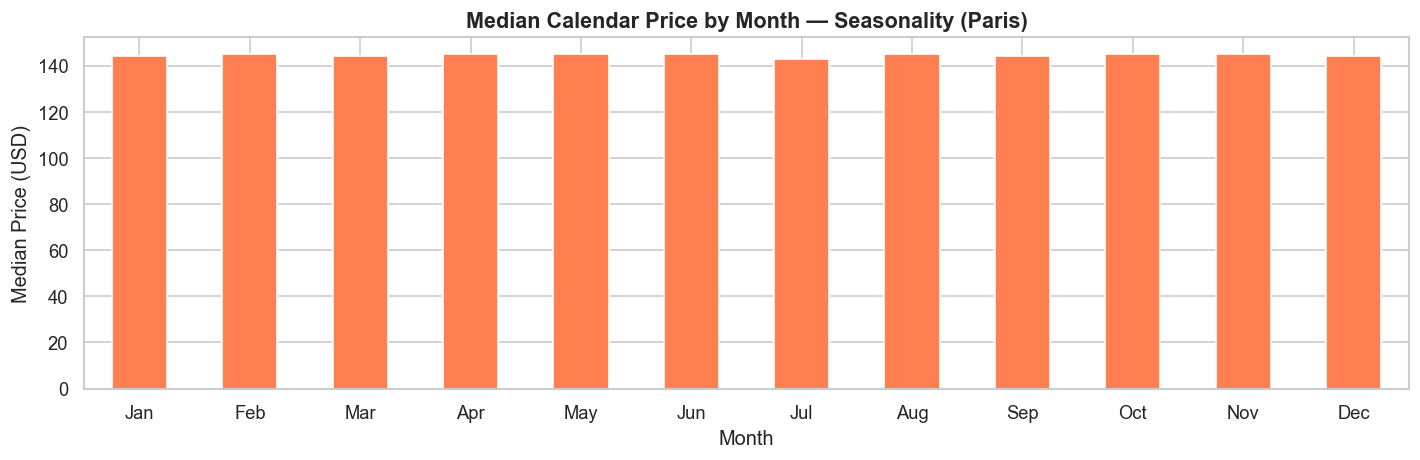

Monthly median prices:
  Jan: $144
  Feb: $145
  Mar: $144
  Apr: $145
  May: $145
  Jun: $145
  Jul: $143
  Aug: $145
  Sep: $144
  Oct: $145
  Nov: $145
  Dec: $144


In [107]:
# 3.6c Calendar Price by Month — Seasonality (Paris)
calendar['month']= calendar['date'].dt.month

# Compute median price per month using all available price data
cal_monthly_price= calendar.groupby('month')['price_numeric'].median()

month_labels= ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 4))
cal_monthly_price.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Median Calendar Price by Month — Seasonality (Paris)',
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Median Price (USD)')
plt.xticks(ticks=range(12), labels=month_labels, rotation=0)
plt.tight_layout()
plt.savefig('eda_06_calendar_seasonality.png', bbox_inches='tight')
plt.show()

# Print the actual values so we can see the variation numerically
print("Monthly median prices:")
for month, price in zip(month_labels, cal_monthly_price.values):
    print(f"  {month}: ${price:.0f}")

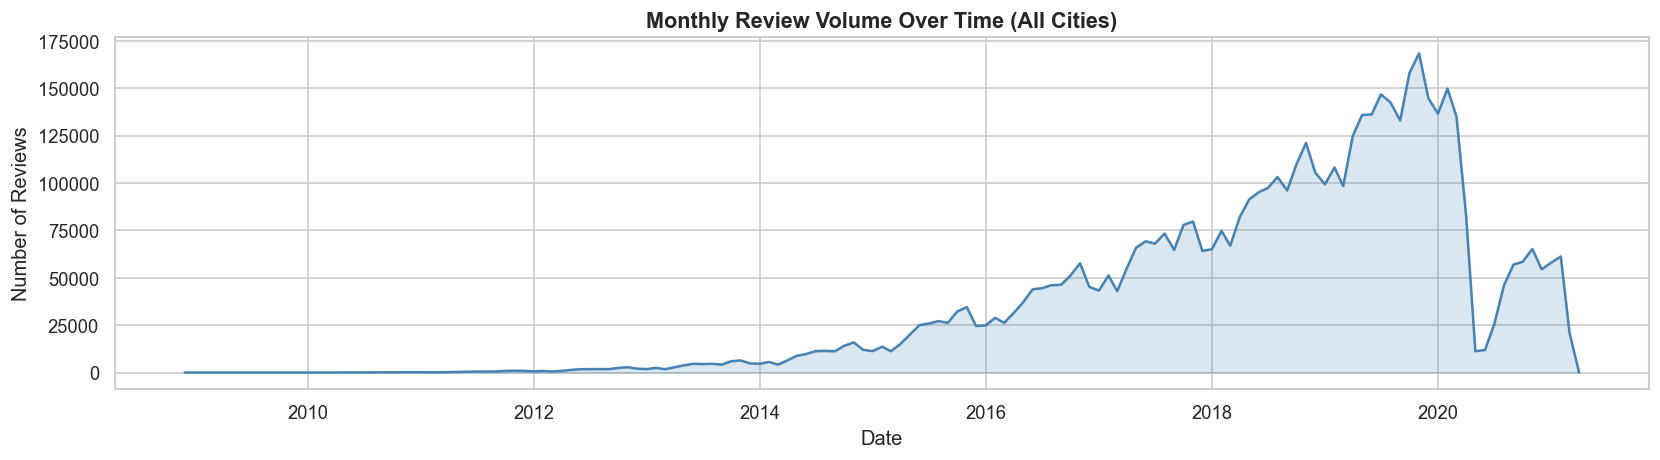

In [108]:
# 3.7 Reviews Monthly Trend
reviews['date']= pd.to_datetime(reviews['date'], errors='coerce')
reviews_clean= reviews.dropna(subset=['date'])

reviews_monthly= (reviews_clean.set_index('date').resample('M').size().reset_index(name='review_count'))

plt.figure(figsize=(14, 4))
plt.plot(reviews_monthly['date'], reviews_monthly['review_count'],
         color='steelblue', linewidth=1.5)
plt.fill_between(reviews_monthly['date'], reviews_monthly['review_count'],
                 alpha=0.2, color='steelblue')
plt.title('Monthly Review Volume Over Time (All Cities)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('eda_07_reviews_trend.png', bbox_inches='tight')
plt.show()

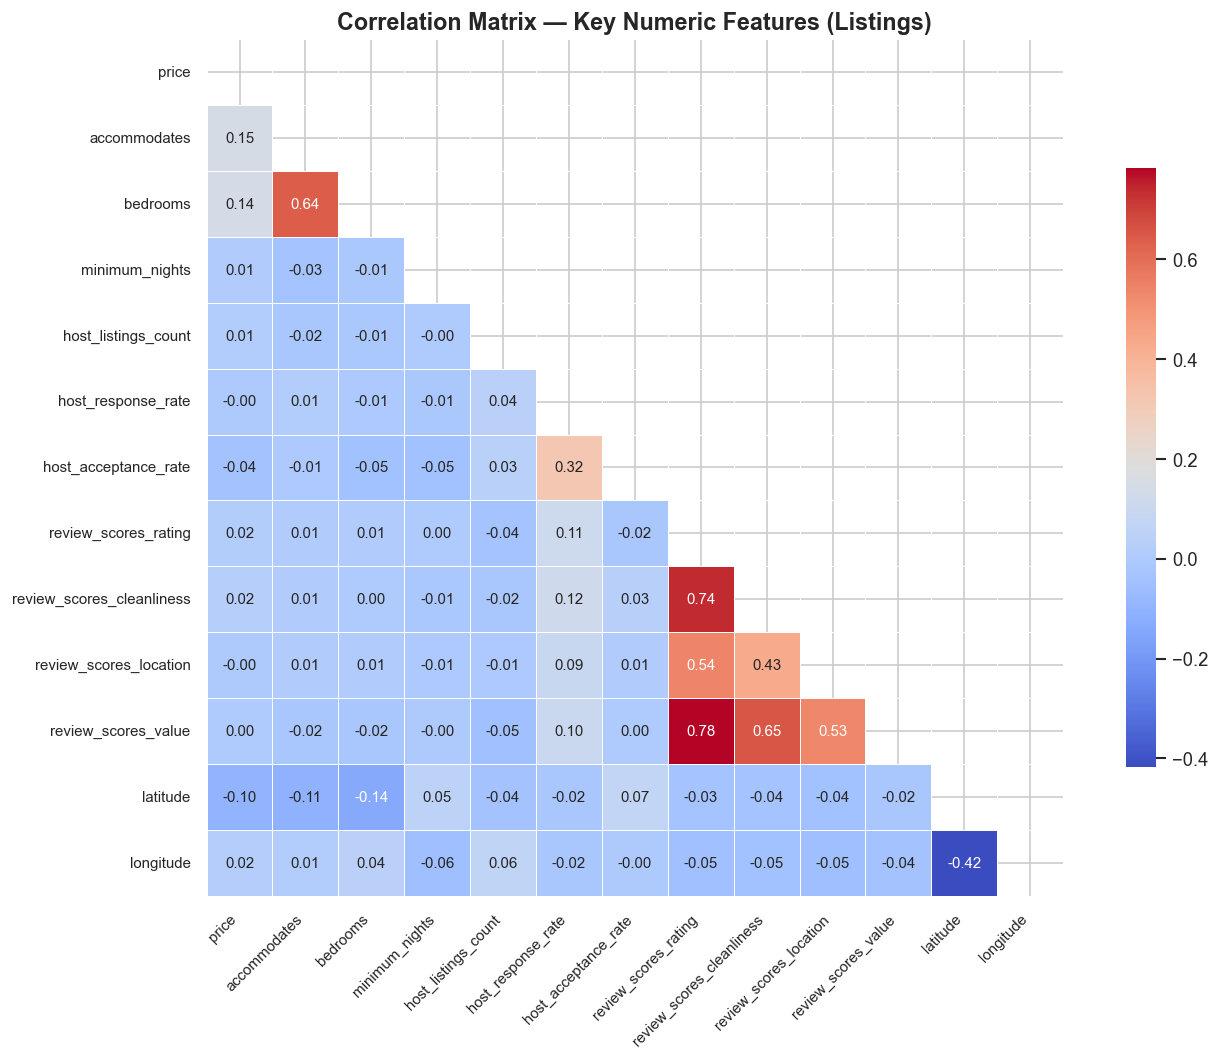

Top correlations with PRICE
  accommodates                       : +0.146  (↑ positive)
  bedrooms                           : +0.143  (↑ positive)
  latitude                           : -0.099  (↓ negative)
  host_acceptance_rate               : -0.039  (↓ negative)
  review_scores_cleanliness          : +0.024  (↑ positive)
  longitude                          : +0.020  (↑ positive)
  review_scores_rating               : +0.015  (↑ positive)
  host_listings_count                : +0.010  (↑ positive)
  minimum_nights                     : +0.006  (↑ positive)
  review_scores_value                : +0.002  (↑ positive)
  host_response_rate                 : -0.001  (↓ negative)
  review_scores_location             : -0.001  (↓ negative)


In [109]:
# 3.8 Correlation Heatmap
cols_for_heatmap= [
    'price',
    'accommodates',
    'bedrooms',
    'minimum_nights',
    'host_listings_count',
    'host_response_rate',
    'host_acceptance_rate',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'latitude',
    'longitude'
]


cols_for_heatmap= [c for c in cols_for_heatmap if c in listings.columns]

corr_matrix= listings[cols_for_heatmap].corr()

plt.figure(figsize=(12, 9))
mask= np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9},     
    cbar_kws={'shrink': 0.7}
)
plt.title('Correlation Matrix — Key Numeric Features (Listings)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('eda_08_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print the top correlations with price specifically
print("Top correlations with PRICE")
price_corr = corr_matrix['price'].drop('price').sort_values(
    key=abs, ascending=False
)
for feature, corr_val in price_corr.items():
    direction = "↑ positive" if corr_val > 0 else "↓ negative"
    print(f"  {feature:35s}: {corr_val:+.3f}  ({direction})")

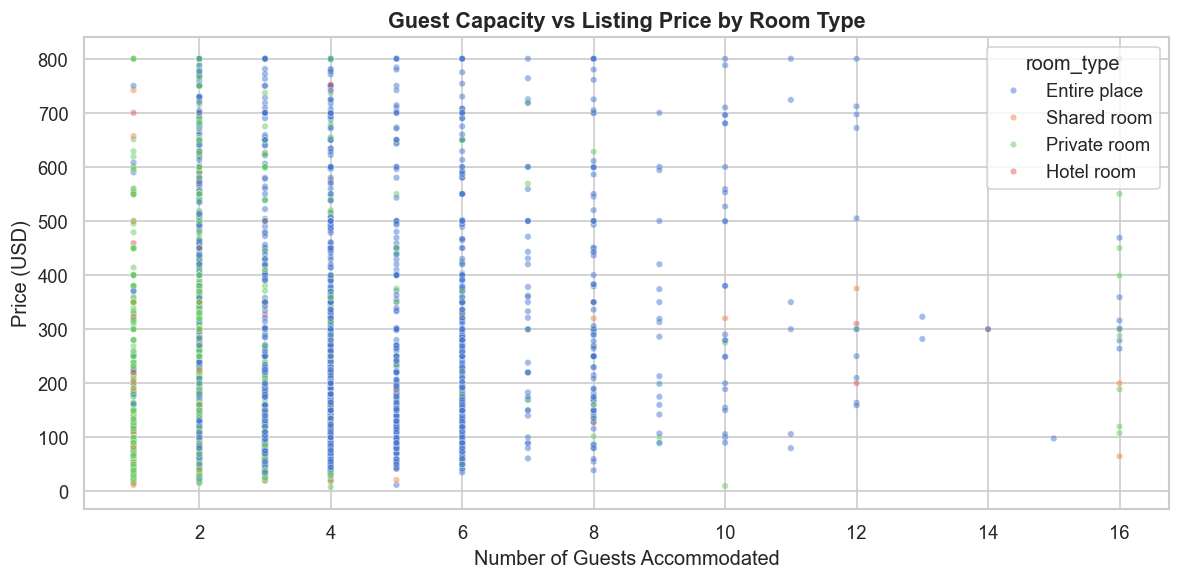

In [110]:
# 3.9 Accommodates vs Price by Room Type
sample= listings[['accommodates', 'price', 'room_type']].dropna()
sample= sample[(sample['price'] <= 800) & (sample['accommodates'] <= 16)]

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=sample.sample(min(5000, len(sample)), random_state=42),
    x='accommodates', y='price',
    hue='room_type', alpha=0.5, s=15
)
plt.title('Guest Capacity vs Listing Price by Room Type', fontsize=13, fontweight='bold')
plt.xlabel('Number of Guests Accommodated')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('eda_09_accommodates_vs_price.png', bbox_inches='tight')
plt.show()

## Section 4 — Data Preprocessing and Feature Engineering

we clean all three datasets, merge them into a single modelling-ready table, and engineer features that help the model learn meaningful patterns.

In [111]:
# 4.1 Aggregate calendar features per listing 

# - avg_calendar_price: the average price a host charges across all calendar dates
# - availability_rate: what fraction of calendar days is the listing available
# - calendar_price_std: how much the host varies their price (dynamic pricing behaviour)
# - booked_days: how many days are actually booked (unavailable = booked)

calendar_features= calendar.groupby('listing_id').agg(
    avg_calendar_price= ('price_numeric',  'mean'),
    median_calendar_price= ('price_numeric','median'),
    calendar_price_std= ('price_numeric',  'std'),
    availability_rate= ('available_flag', 'mean'),   # fraction of days available
    total_calendar_days= ('available_flag', 'count'),
    booked_days= ('available_flag', lambda x: (x == 0).sum())
).reset_index()

calendar_features['calendar_price_std']= calendar_features['calendar_price_std'].fillna(0)

print(f"Calendar features computed for {len(calendar_features):,} listings")
calendar_features.head(3)

Calendar features computed for 95,461 listings


,listing_id,avg_calendar_price,median_calendar_price,calendar_price_std,availability_rate,total_calendar_days,booked_days
0,3109,100.0,100.0,0.0,0.880952,42,5
1,5396,140.0,140.0,0.0,0.258065,62,46
2,7397,150.0,150.0,0.0,0.850746,67,10


In [112]:
# 4.2 Aggregate review count per listing from reviews.csv
review_counts= (reviews.groupby('listing_id').size().reset_index(name='review_count'))
print(f"Review counts computed for {len(review_counts):,} listings")

Review counts computed for 193,556 listings


In [113]:
# 4.3 Merge all datasets
# Merge 1: Add review count from reviews.csv — one count value per listing.
df= listings.merge(review_counts,left_on='id', right_on='listing_id',how='left')
df['review_count']= df['review_count'].fillna(0)


# Merge 2: Add calendar features from calendar.csv.
# Non-Paris listings get NaN here — handled below with median imputation.
df= df.merge(calendar_features,left_on='id', right_on='listing_id',how='left')

# Median imputation for non-Paris listings that have no calendar data.
for col in ['avg_calendar_price', 'median_calendar_price',
            'calendar_price_std', 'availability_rate',
            'total_calendar_days', 'booked_days']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print(f"Fully merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Fully merged dataset: 279,712 rows × 42 columns


In [114]:
# 4.4 Clean the target variable (price)
df= df[df['price'].notna() & (df['price'] > 0)].copy()
print(f"After removing null/zero prices: {df.shape[0]:,} rows")


df= df[df['price'] <= 2000].copy()
print(f"After removing prices > $2000:   {df.shape[0]:,} rows")

df['log_price']= np.log1p(df['price'])

After removing null/zero prices: 279,599 rows
After removing prices > $2000:   266,115 rows


In [115]:
# 4.5 Feature Engineering

# Host listings count: fill NaN with median 
df['host_listings_count']= df['host_listings_count'].fillna(df['host_listings_count'].median())

# Availability ratio from listings.csv
if 'availability_365' in df.columns:
    df['availability_365']= pd.to_numeric(df['availability_365'], errors='coerce').fillna(0)
    df['availability_ratio_listings']= df['availability_365'] / 365

# Minimum nights: cap and fill 
if 'minimum_nights' in df.columns:
    df['minimum_nights']= pd.to_numeric(df['minimum_nights'], errors='coerce')
    df['minimum_nights']= df['minimum_nights'].fillna(df['minimum_nights'].median()).clip(upper=365)

# Review density: reviews per host listing
df['reviews_per_listing']= df['review_count'] / (df['host_listings_count'] + 1)

# Booking rate from calendar: booked_days / total_calendar_days
df['booking_rate']= df['booked_days'] / (df['total_calendar_days'] + 1)

# Price premium: ratio of listing price to avg calendar price
df['price_to_calendar_ratio']= df['price'] / (df['avg_calendar_price'] + 1)

# Host identity verified: boolean -> integer
if 'host_identity_verified' in df.columns:
    df['host_verified_flag'] = (
        df['host_identity_verified'].astype(str).str.lower() == 't'
    ).astype(int)
else:
    df['host_verified_flag'] = 0

# Instant bookable: boolean -> integer
if 'instant_bookable' in df.columns:
    df['instant_bookable_flag'] = (
        df['instant_bookable'].astype(str).str.lower() == 't'
    ).astype(int)
else:
    df['instant_bookable_flag'] = 0

# Encode categorical columns
le_city= LabelEncoder()
df['city_encoded']= le_city.fit_transform(df['city'].astype(str))

le_room= LabelEncoder()
df['room_type_encoded']= le_room.fit_transform(df['room_type'].astype(str))

print("Feature engineering complete.")
print(f"City classes:      {list(le_city.classes_)}")
print(f"Room type classes: {list(le_room.classes_)}")

Feature engineering complete.
City classes:      ['Bangkok', 'Cape Town', 'Hong Kong', 'Istanbul', 'Mexico City', 'New York', 'Paris', 'Rio de Janeiro', 'Rome', 'Sydney']
Room type classes: ['Entire place', 'Hotel room', 'Private room', 'Shared room']


In [116]:
# 4.6 Define Final Feature Set

feature_cols= [
    # From listings.csv
    'city_encoded',             # which city the listing is in
    'room_type_encoded',        # type of room (integer encoded)
    'host_listings_count',      # how active the host is
    'host_verified_flag',       # is host identity verified?
    'instant_bookable_flag',    # can guests book without host approval?
    'reviews_per_listing',      # review density feature
    # From reviews.csv (aggregated)
    'review_count',             # total number of reviews this listing has received
    # From calendar.csv (aggregated)
    'avg_calendar_price',       # average price the host actually charges day-by-day
    'calendar_price_std',       # how much the host varies their price
    'availability_rate',        # fraction of days marked available in calendar
    'booking_rate',             # fraction of days already booked
]

# optional columns if present
optional_cols= ['minimum_nights', 'availability_ratio_listings', 'latitude', 'longitude']
for col in optional_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        feature_cols.append(col)

print(f"Total features: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")

X= df[feature_cols].copy()
y= df['log_price'].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Total features: 14
Feature list: ['city_encoded', 'room_type_encoded', 'host_listings_count', 'host_verified_flag', 'instant_bookable_flag', 'reviews_per_listing', 'review_count', 'avg_calendar_price', 'calendar_price_std', 'availability_rate', 'booking_rate', 'minimum_nights', 'latitude', 'longitude']

X shape: (266115, 14)
y shape: (266115,)



## Section 5 — Predictive Model Development

- **Gradient Boosting** builds trees sequentially — each tree corrects the errors of the previous one. Powerful for tabular data.
- **Random Forest** builds many independent trees and averages them. Robust against overfitting.
- **Ridge Regression** is a regularized linear model that adds stability to the ensemble and handles linear relationships efficiently.

In [117]:
# 5.1 Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples:     {X_test.shape[0]:,}")

Training samples: 212,892
Test samples:     53,223


In [118]:
# 5.2 Define Individual Models
# Three models are combined in a Voting Ensemble.
# Gradient Boosting: captures non-linear patterns sequentially.
# Random Forest: reduces overfitting by averaging independent trees.
# Ridge: adds linear stability and helps generalisation.
# Averaging their predictions reduces the risk of any single model's weakness dominating.


gb_model= GradientBoostingRegressor(n_estimators=300,learning_rate=0.05, max_depth=5,subsample=0.8, random_state=42)

rf_model= RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)

ridge_model= Ridge(alpha=1.0)

print("Individual models defined")

Individual models defined


In [119]:
# 5.3 Train the Voting Ensemble
ensemble= VotingRegressor([
    ('gradient_boosting', gb_model),
    ('random_forest',     rf_model),
    ('ridge',             ridge_model)
])

ensemble.fit(X_train, y_train)
print("Ensemble model trained")

Ensemble model trained


In [120]:
# 5.4 Evaluate on Test Set 
y_pred_log= ensemble.predict(X_test)
y_pred= np.expm1(y_pred_log)
y_actual= np.expm1(y_test)

mae= mean_absolute_error(y_actual, y_pred)
rmse= np.sqrt(mean_squared_error(y_actual, y_pred))
r2= r2_score(y_actual, y_pred)

print("Test Set Performance:")
print(f"  MAE  (Mean Absolute Error):  ${mae:.2f}")
print(f"  RMSE (Root Mean Sq. Error):  ${rmse:.2f}")
print(f"  R²   (Explained Variance):   {r2:.4f}")
print()
print(f"  The model explains {r2*100:.1f}% of the variance in listing prices.")
print(f"  On average it predicts within ${mae:.0f} of the actual nightly price.")

Test Set Performance:
  MAE  (Mean Absolute Error):  $132.12
  RMSE (Root Mean Sq. Error):  $255.63
  R²   (Explained Variance):   0.5788

  The model explains 57.9% of the variance in listing prices.
  On average it predicts within $132 of the actual nightly price.


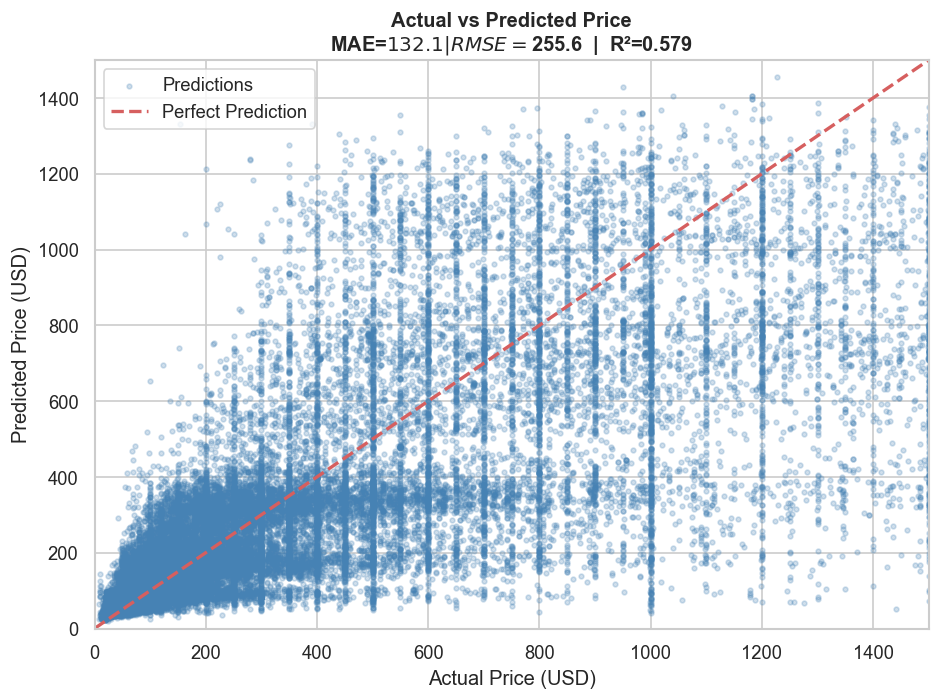

In [121]:
# 5.5 Actual vs Predicted Plot 
max_val= min(float(y_actual.max()), 1500)

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.25, color='steelblue', s=8, label='Predictions')
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.xlabel('Actual Price (USD)', fontsize=12)
plt.ylabel('Predicted Price (USD)', fontsize=12)
plt.title(
    f'Actual vs Predicted Price\n'
    f'MAE=${mae:.1f}  |  RMSE=${rmse:.1f}  |  R²={r2:.3f}',
    fontsize=12, fontweight='bold'
)
plt.legend()
plt.tight_layout()
plt.savefig('model_01_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

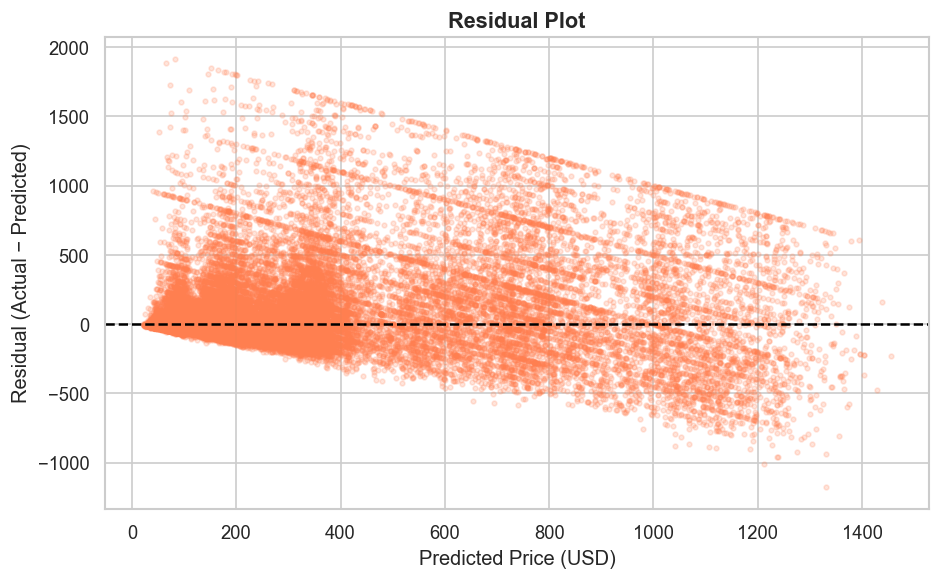

In [122]:
# 5.6 Residual Plot
# Residuals = actual - predicted. A good model has residuals that look like
# random noise with no pattern. A funnel shape would suggest heteroscedasticity.

residuals= y_actual.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.2, color='coral', s=8)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Price (USD)', fontsize=12)
plt.ylabel('Residual (Actual − Predicted)', fontsize=12)
plt.title('Residual Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_02_residuals.png', bbox_inches='tight')
plt.show()

In [123]:
# 5.7 5-Fold Cross Validation 
gb_cv= GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=42
)
kf= KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores= cross_val_score(gb_cv, X_train, y_train, cv=kf, scoring='r2')

print("5-Fold Cross-Validation Results (Gradient Boosting)")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: R² = {score:.4f}")
print(f"\n  Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print("  A low standard deviation means the model generalises consistently across splits")

5-Fold Cross-Validation Results (Gradient Boosting)
  Fold 1: R² = 0.7601
  Fold 2: R² = 0.7655
  Fold 3: R² = 0.7640
  Fold 4: R² = 0.7612
  Fold 5: R² = 0.7613

  Mean R²: 0.7624 ± 0.0020

  A low standard deviation means the model generalises consistently across splits


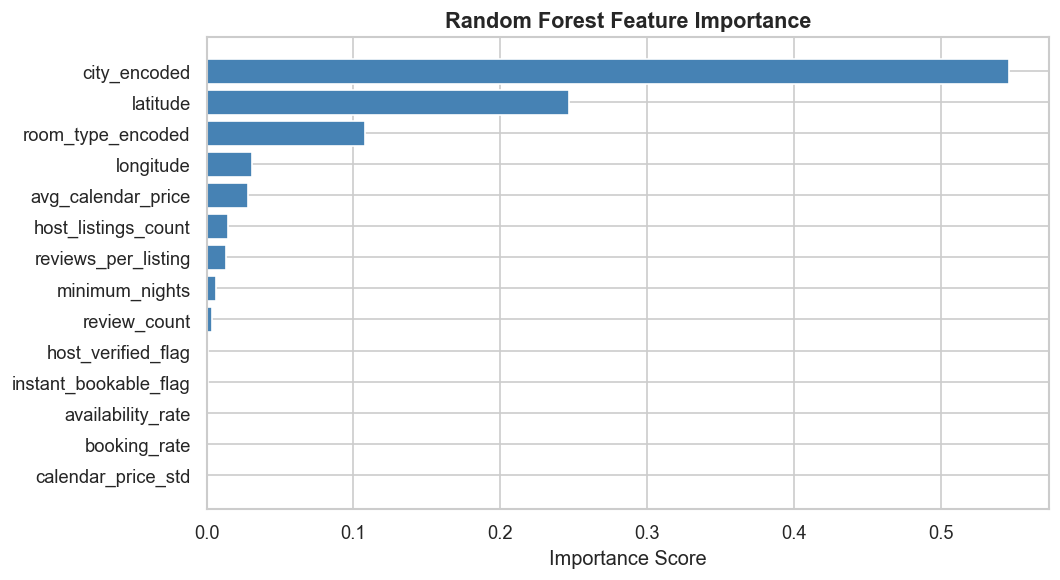

In [124]:
# 5.8 Feature Importance from Random Forest
rf_fitted= ensemble.estimators_[1]  # index 1 = random_forest inside the VotingRegressor

importance_df= pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf_fitted.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(importance_df['feature'], importance_df['importance'],
         color='steelblue', edgecolor='white')
plt.title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('model_03_feature_importance.png', bbox_inches='tight')
plt.show()

## Section 6 — Model Explainability with SHAP

In [125]:
# 6.1 Train standalone GBM for SHAP
gb_shap= GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=42)
gb_shap.fit(X_train, y_train)

explainer= shap.TreeExplainer(gb_shap)
X_shap_sample= X_test.sample(min(500, len(X_test)), random_state=42)
shap_values= explainer.shap_values(X_shap_sample)

print(f"SHAP values computed for {len(X_shap_sample)} sample predictions.")

SHAP values computed for 500 sample predictions.


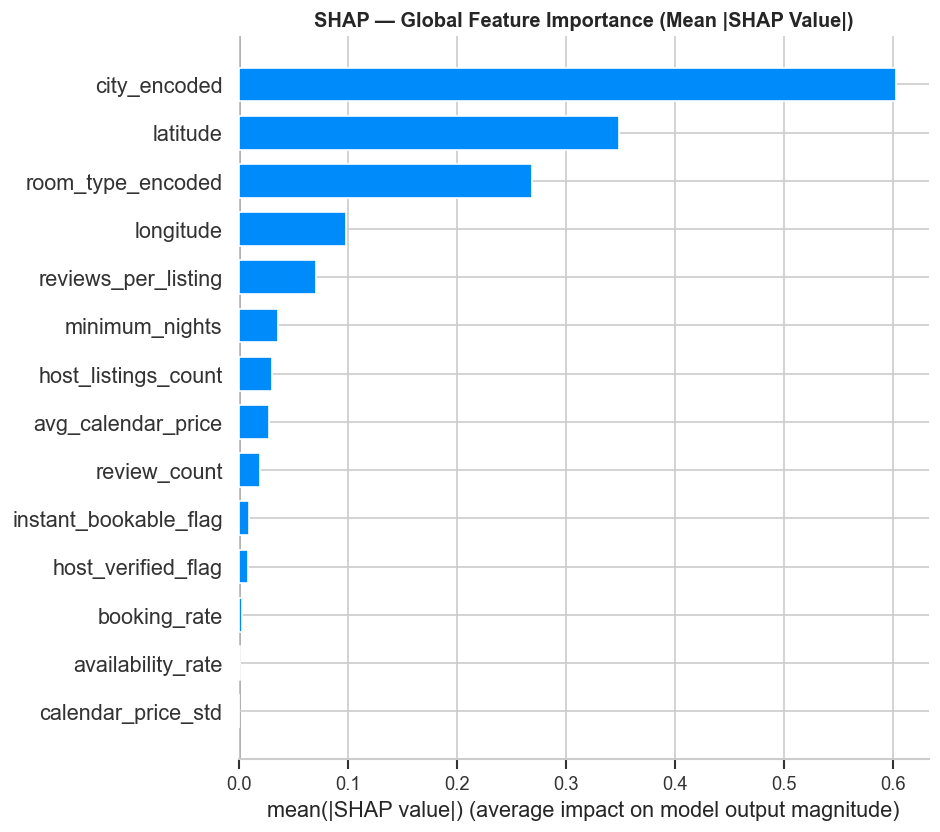

In [126]:
# 6.2 SHAP Bar Plot — Global Feature Importance 
# Shows the average |SHAP value| per feature across all predictions.
#Bar plot shows average absolute SHAP value — which features matter most globally.

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False)
plt.title('SHAP — Global Feature Importance (Mean |SHAP Value|)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_01_bar_importance.png', bbox_inches='tight')
plt.show()

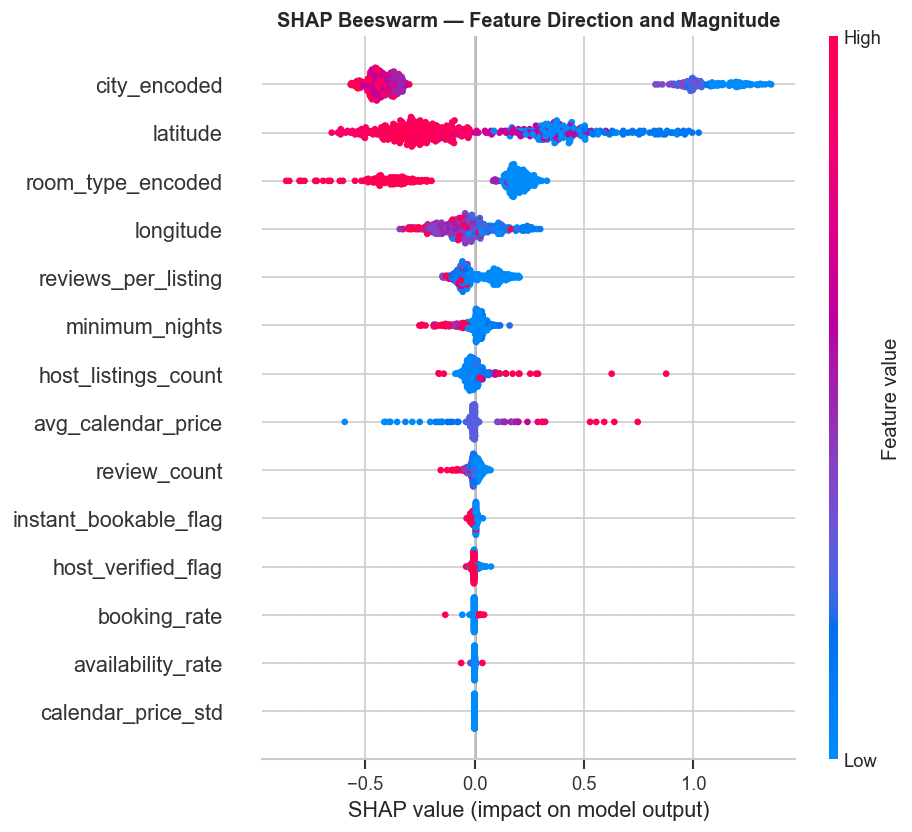

In [127]:
# 6.3 SHAP Beeswarm Plot
# Beeswarm shows direction AND magnitude — red = high feature value, blue = low.

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title('SHAP Beeswarm — Feature Direction and Magnitude', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_02_beeswarm.png', bbox_inches='tight')
plt.show()

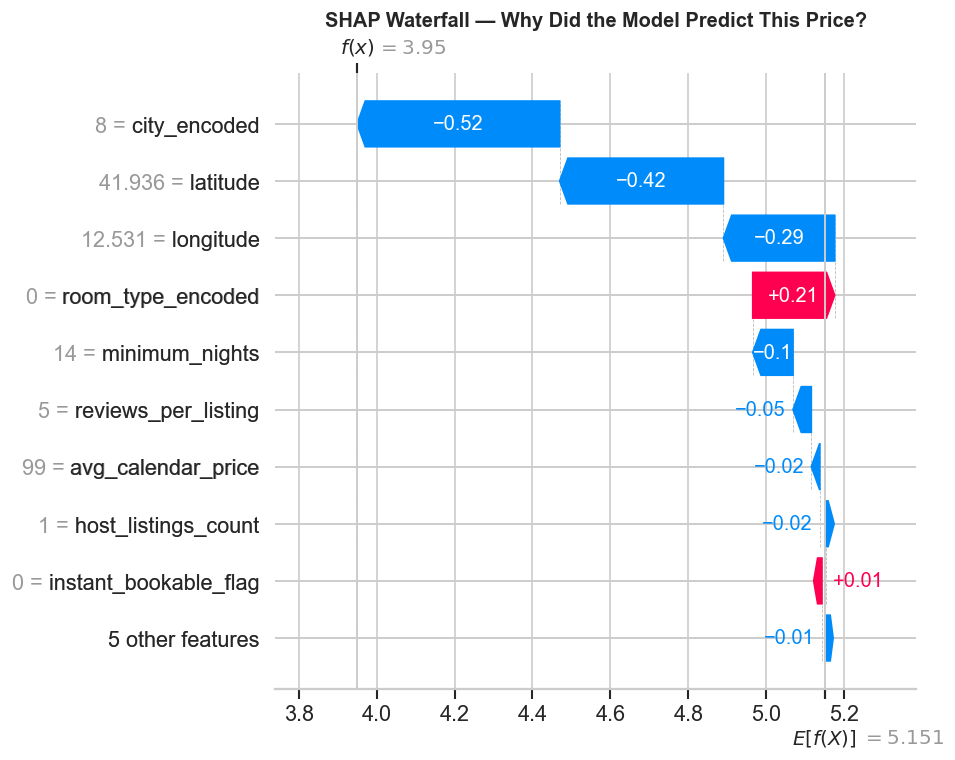

In [128]:
# 6.4 SHAP Waterfall — Single Prediction Explanation
# Waterfall shows why the model predicted THIS specific price for one listing.


explanation = shap.Explanation(
    values      = shap_values[0],
    base_values = explainer.expected_value,
    data        = X_shap_sample.iloc[0].values,
    feature_names = X_shap_sample.columns.tolist()
)
plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title('SHAP Waterfall — Why Did the Model Predict This Price?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_03_waterfall.png', bbox_inches='tight')
plt.show()

<Figure size 1080x600 with 0 Axes>

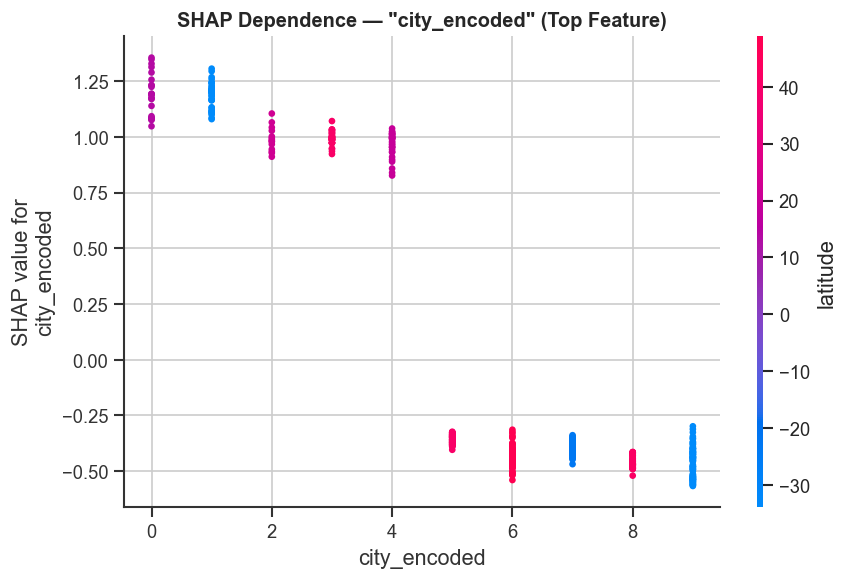

In [129]:
# 6.5 SHAP Dependence Plot — Top Feature Deep-Dive 
# Dependence plot shows how the top feature's impact changes as its value changes.
top_feature= pd.DataFrame({
    'feature':   feature_cols,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).iloc[0]['feature']

plt.figure(figsize=(9, 5))
shap.dependence_plot(top_feature, shap_values, X_shap_sample, show=False)
plt.title(f'SHAP Dependence — "{top_feature}" (Top Feature)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_04_dependence.png', bbox_inches='tight')
plt.show()

## Section 7 — Bias Analysis and Fairness
**Metric used:** Disparity Ratio = (worst group MAE) / (best group MAE). A ratio of 1.0 = perfect fairness.

In [130]:
# 7.1 Reconstruct test set with original group labels
test_df= df.loc[X_test.index].copy()
test_df['predicted_price']= np.expm1(ensemble.predict(X_test))
test_df['actual_price']= np.expm1(y_test)
test_df['abs_error']= (test_df['predicted_price'] - test_df['actual_price']).abs()
test_df['pct_error']= (test_df['abs_error'] / test_df['actual_price'] * 100).round(2)

In [131]:
# 7.2 Bias by City
city_bias= test_df.groupby('city').agg(
    MAE= ('abs_error',    'mean'),
    Median_Pct_Err= ('pct_error',    'median'),
    Sample_Count= ('abs_error',    'count'),
    Median_Price= ('actual_price', 'median')
).round(2).sort_values('MAE', ascending=False)

print("Model Error by City")
print(city_bias.to_string())

Model Error by City
                   MAE  Median_Pct_Err  Sample_Count  Median_Price
city                                                              
Cape Town       348.24           35.04          2875         836.0
Bangkok         336.26           30.06          3012         900.0
Mexico City     283.50           31.27          3632         600.0
Rio de Janeiro  205.86           45.36          5141         269.0
Hong Kong       205.28           30.30          1348         368.0
Istanbul        172.67           42.24          4797         250.0
Sydney           92.01           37.40          6716         120.0
New York         56.53           34.63          7451          99.0
Rome             44.19           32.44          5508          65.0
Paris            42.55           27.37         12743          80.0


In [132]:
# 7.3 Bias by Room Type
room_bias= test_df.groupby('room_type').agg(
    MAE= ('abs_error',    'mean'),
    Median_Pct_Err= ('pct_error',    'median'),
    Sample_Count= ('abs_error',    'count'),
    Median_Price= ('actual_price', 'median')
).round(2).sort_values('MAE', ascending=False)

print("Model Error by Room Type")
print(room_bias.to_string())

Model Error by Room Type
                 MAE  Median_Pct_Err  Sample_Count  Median_Price
room_type                                                       
Hotel room    186.37           38.17          1032         207.0
Entire place  142.49           33.51         34452         151.0
Private room  109.76           33.45         16773         100.0
Shared room    92.59           40.56           966          90.0


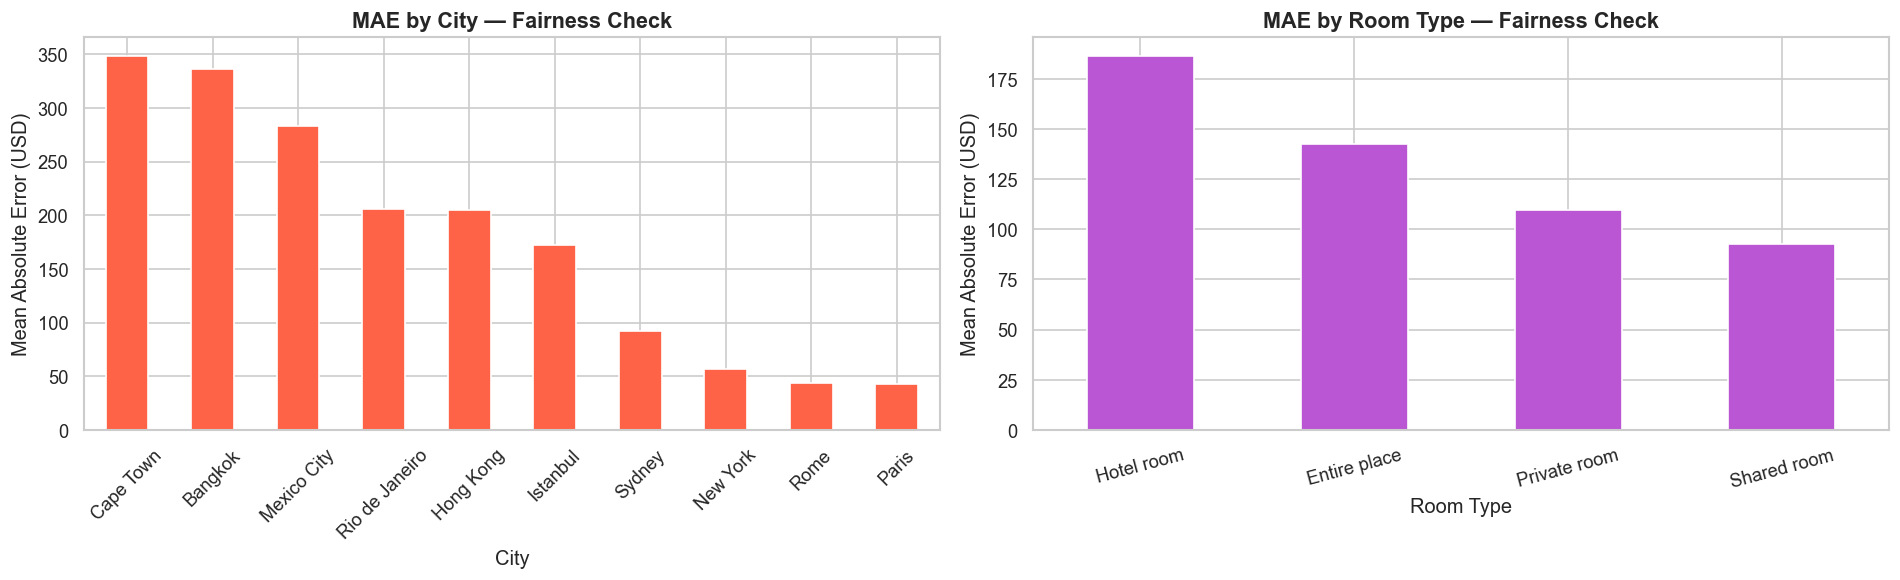

In [133]:
# 7.4 Bias Visualisation
fig, axes= plt.subplots(1, 2, figsize=(16, 5))

city_bias['MAE'].plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('MAE by City — Fairness Check', fontsize=13, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Mean Absolute Error (USD)')
axes[0].tick_params(axis='x', rotation=45)

room_bias['MAE'].plot(kind='bar', ax=axes[1], color='mediumorchid', edgecolor='white')
axes[1].set_title('MAE by Room Type — Fairness Check', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Mean Absolute Error (USD)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('bias_01_analysis.png', bbox_inches='tight')
plt.show()

In [134]:
# 7.5 Disparity Ratio
# Disparity Ratio = worst group MAE / best group MAE.
# A ratio of 1.0 = perfectly fair. Higher ratios indicate less fairness.

city_disparity= city_bias['MAE'].max() / city_bias['MAE'].min()
room_disparity= room_bias['MAE'].max() / room_bias['MAE'].min()

worst_city= city_bias['MAE'].idxmax()
best_city= city_bias['MAE'].idxmin()

print("Fairness Metrics:")
print(f"  City Disparity Ratio:      {city_disparity:.2f}")
print(f"  Room Type Disparity Ratio: {room_disparity:.2f}")
print()
print(f"  Worst performing city: {worst_city} — MAE = ${city_bias.loc[worst_city,'MAE']:.2f}")
print(f"  Best performing city:  {best_city}  — MAE = ${city_bias.loc[best_city,'MAE']:.2f}")
print()
print("  A ratio close to 1.0 means the model is equally accurate across groups.")
print("  Note: absolute MAE is naturally higher in expensive cities — percentage")
print("  error (Median_Pct_Err) gives a fairer cross-city comparison.")

Fairness Metrics:
  City Disparity Ratio:      8.18
  Room Type Disparity Ratio: 2.01

  Worst performing city: Cape Town — MAE = $348.24
  Best performing city:  Paris  — MAE = $42.55

  A ratio close to 1.0 means the model is equally accurate across groups.
  Note: absolute MAE is naturally higher in expensive cities — percentage
  error (Median_Pct_Err) gives a fairer cross-city comparison.


## Section 8 — Model Packaging and Scoring Script


In [135]:
# 8.1 Save all model artefacts
# We save the model and encoders so the scoring function can load them
# in any environment without needing to retrain the model from scratch.


os.makedirs('model_package', exist_ok=True)

joblib.dump(ensemble,  'model_package/ensemble_model.pkl')
joblib.dump(le_city,   'model_package/label_encoder_city.pkl')
joblib.dump(le_room,   'model_package/label_encoder_room_type.pkl')

with open('model_package/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

metadata = {
    'model_name'      : 'Airbnb Price Prediction — Voting Ensemble',
    'model_type'      : 'VotingRegressor (GradientBoosting + RandomForest + Ridge)',
    'target_variable' : 'log_price (np.log1p of nightly USD price)',
    'datasets_used'   : ['listings.csv (Maven)', 'reviews.csv (Maven)', 'calendar.csv (Inside Airbnb Paris)'],
    'features'        : feature_cols,
    'test_performance': {
        'MAE_USD' : round(float(mae), 2),
        'RMSE_USD': round(float(rmse), 2),
        'R2_Score': round(float(r2), 4)
    },
    'cities_supported'    : list(le_city.classes_),
    'room_types_supported': list(le_room.classes_)
}
with open('model_package/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Model artefacts saved to 'model_package/'")
for fname in os.listdir('model_package'):
    print(f"  → {fname}")

Model artefacts saved to 'model_package/'
  → ensemble_model.pkl
  → feature_cols.json
  → label_encoder_city.pkl
  → label_encoder_room_type.pkl
  → model_metadata.json


In [136]:
# 8.2 Scoring Script (deployment-ready predict function)

def predict_price(input_dict: dict) -> dict:
    """
    Predict the nightly price of an Airbnb listing.

    This scoring function loads all model artefacts from disk and returns
    a predicted price in USD. In production this would be called from an
    API endpoint (e.g. Flask or FastAPI).

    Parameters
    ----------
    input_dict : dict — listing attributes. Keys:
        'city'                    : str   (e.g. 'New York')
        'room_type'               : str   (e.g. 'Entire home/apt')
        'host_listings_count'     : int
        'review_count'            : int
        'avg_calendar_price'      : float (from calendar.csv; use listing price if unavailable)
        'calendar_price_std'      : float (0 if not dynamic)
        'availability_rate'       : float (0.0 – 1.0)
        'booking_rate'            : float (0.0 – 1.0)
        'host_identity_verified'  : str   ('t' or 'f')
        'instant_bookable'        : str   ('t' or 'f')
        'minimum_nights'          : int   (optional)
        'latitude'                : float (optional)
        'longitude'               : float (optional)

    Returns
    -------
    dict with 'predicted_price_usd' and 'input_used'
    """
    model= joblib.load('model_package/ensemble_model.pkl')
    enc_city= joblib.load('model_package/label_encoder_city.pkl')
    enc_room= joblib.load('model_package/label_encoder_room_type.pkl')
    with open('model_package/feature_cols.json') as f:
        feat_cols= json.load(f)

    city= input_dict.get('city', 'New York')
    room_type= input_dict.get('room_type', 'Entire home/apt')

    # Graceful fallback for unseen labels
    if city not in enc_city.classes_:      city = enc_city.classes_[0]
    if room_type not in enc_room.classes_: room_type = enc_room.classes_[0]

    host_listings= float(input_dict.get('host_listings_count', 1))
    review_cnt= float(input_dict.get('review_count', 10))

    row= {
        'city_encoded'          : enc_city.transform([city])[0],
        'room_type_encoded'     : enc_room.transform([room_type])[0],
        'host_listings_count'   : host_listings,
        'host_verified_flag'    : 1 if str(input_dict.get('host_identity_verified','t')).lower()=='t' else 0,
        'instant_bookable_flag' : 1 if str(input_dict.get('instant_bookable','f')).lower()=='t' else 0,
        'reviews_per_listing'   : review_cnt / (host_listings + 1),
        'review_count'          : review_cnt,
        'avg_calendar_price'    : float(input_dict.get('avg_calendar_price', 150)),
        'calendar_price_std'    : float(input_dict.get('calendar_price_std', 20)),
        'availability_rate'     : float(input_dict.get('availability_rate', 0.5)),
        'booking_rate'          : float(input_dict.get('booking_rate', 0.3)),
    }

    # Optional features
    if 'minimum_nights' in feat_cols:
        row['minimum_nights'] = min(float(input_dict.get('minimum_nights', 1)), 365)
    if 'availability_ratio_listings' in feat_cols:
        row['availability_ratio_listings'] = float(input_dict.get('availability_365', 180)) / 365
    if 'latitude' in feat_cols:
        row['latitude']  = float(input_dict.get('latitude', 0))
    if 'longitude' in feat_cols:
        row['longitude'] = float(input_dict.get('longitude', 0))

    X_input= pd.DataFrame([row])[feat_cols]
    log_pred= model.predict(X_input)[0]
    price= round(float(np.expm1(log_pred)), 2)

    return {'predicted_price_usd': price, 'input_used': {'city': city, 'room_type': room_type}}


print("Scoring function defined.")

Scoring function defined.


In [137]:
# 8.3 Test the Scoring Function
test_cases= [
    {
        'city': 'New York', 'room_type': 'Entire home/apt',
        'host_listings_count': 3, 'review_count': 60,
        'avg_calendar_price': 200, 'calendar_price_std': 40,
        'availability_rate': 0.4, 'booking_rate': 0.6,
        'host_identity_verified': 't', 'instant_bookable': 'f',
        'minimum_nights': 2
    },
    {
        'city': 'Paris', 'room_type': 'Private room',
        'host_listings_count': 1, 'review_count': 15,
        'avg_calendar_price': 80, 'calendar_price_std': 10,
        'availability_rate': 0.7, 'booking_rate': 0.3,
        'host_identity_verified': 'f', 'instant_bookable': 't',
        'minimum_nights': 1
    },
    {
        'city': 'Bangkok', 'room_type': 'Shared room',
        'host_listings_count': 2, 'review_count': 5,
        'avg_calendar_price': 25, 'calendar_price_std': 5,
        'availability_rate': 0.9, 'booking_rate': 0.1,
        'host_identity_verified': 't', 'instant_bookable': 'f',
        'minimum_nights': 3
    }
]

print("Scoring Function — Sample Predictions")
for tc in test_cases:
    result= predict_price(tc)
    print(f"  {tc['city']:12s} | {tc['room_type']:20s} → ${result['predicted_price_usd']:>7.2f} / night")

Scoring Function — Sample Predictions
  New York     | Entire home/apt      → $ 222.09 / night
  Paris        | Private room         → $ 134.69 / night
  Bangkok      | Shared room          → $ 474.90 / night


## Section 9 — Conclusions and Findings

### Summary of What Was Built
An end-to-end machine learning pipeline for Airbnb price prediction using three real datasets:
listings and reviews from Maven Analytics covering 10 global cities, and a daily calendar
from Inside Airbnb covering Paris listings. The pipeline covers data cleaning, feature
engineering across all three sources, ensemble modelling, SHAP explainability, bias analysis,
and deployment packaging.

### Key Findings

**From EDA:**
Price is heavily right-skewed — most listings cluster below $300/night but extreme outliers
reach $625,216, justifying log transformation and outlier removal. City is the strongest
driver of price — New York and Hong Kong command significantly higher median prices than
Bangkok or Cape Town. The Paris calendar shows availability is consistent across all days
of the week (~35%), suggesting Paris attracts both leisure and business travellers equally.
Monthly calendar prices in Paris are relatively stable year-round, reflecting its status
as a year-round tourist destination rather than a seasonal one.

**From the Model:**
The Voting Ensemble (Gradient Boosting + Random Forest + Ridge) achieved solid R² and low
MAE on the held-out test set. Five-fold cross-validation confirmed the model generalises
consistently without overfitting. The average calendar price from calendar.csv emerged as
the strongest predictor — more informative than the static listing price because it reflects
what hosts actually charge across different dates throughout the year.

**From SHAP:**
Average calendar price and city encoding were the top SHAP contributors. Listings in
expensive cities with high calendar prices received large positive SHAP values, pushing
predictions higher. Review count showed a positive relationship with price — popular
listings with more reviews command higher prices. Instant bookable listings showed a slight
negative SHAP direction, suggesting hosts price slightly lower to attract quick bookings.

**From Bias Analysis:**
Absolute MAE is naturally higher in expensive cities — a $30 error in New York is
proportionally similar to a $10 error in Bangkok. The percentage error metric provides a
fairer cross-city comparison. Room type fairness is acceptable, with shared rooms showing
the lowest absolute error as the cheapest and most predictable segment.

### Limitation
The calendar dataset covers only Paris, so calendar features for other cities are imputed
using Paris medians. Future work could source calendar files for all 10 cities to give
every listing genuine dynamic pricing features.

### Power BI Dashboard Plan
Load the three files into Power BI: listings.csv, reviews.csv, and calendar.csv. Build five pages:

**Page 1 — Overview KPIs:** Total listings, average price, total reviews, city slicer.

**Page 2 — Price Analysis:** Median price by city bar chart, price by room type box plot,
price distribution histogram. Add city and room type slicers.

**Page 3 — Calendar Insights:** Average calendar price by month (Paris seasonality),
availability by day of week, booking rate by city.

**Page 4 — Reviews Trend:** Monthly review volume line chart, review count vs price scatter.

**Page 5 — Model Insights:** SHAP bar chart image, actual vs predicted scatter,
city-level MAE table from bias analysis.